# Proyecto 2 – Machine Learning: Detección de Fraudes (V3 Final)

**Cursos:** Machine Learning & Data Discovery  
**Integrantes Grupo 1:** [Nombre 1] · [Nombre 2] · [Nombre 3] · [Nombre 4]  
**Fecha:** 17 de Marzo, 2026

---
*Arquitectura V3: Aplica exhaustivamente toda la bibliografía de clase — Data Leakage, Calidad de Datos, Outliers (IQR), Feature Engineering (Target Encoding + Binning), Multicolinealidad (VIF) + PCA, Clustering (KMeans vs DBSCAN), Rebalanceo Híbrido (SMOTETomek), Boosting (LightGBM vs Logística), Búsqueda de Hiperparámetros y Umbralización Threshold.*

## 1. Introducción y Prevención de Data Leakage (Teoría DD)

El objetivo es maximizar el **F1-Score** en una base asimétrica de transacciones bancarias (~3.5 % fraude).

**Prevención del Data Leakage:** El `Train/Test Split` ocurre **antes** de cualquier transformación. Todo parámetro (medias de Target Encoding, cuartiles de Binning, componentes PCA) se aprende **solo en el conjunto de entrenamiento** y se aplica al de prueba.

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
import lightgbm as lgb, gc, datetime, warnings
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import (roc_auc_score, precision_recall_curve,
                             classification_report, confusion_matrix)
from imblearn.combine import SMOTETomek
from scipy.stats import randint as sp_randint, uniform as sp_uniform
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


## 2. Calidad de Datos – Carga y Optimización de Memoria (Teoría DD)

Descartamos columnas con más del 80 % de valores nulos (dimensión de *Completitud*).

In [2]:
print("Cargando datasets...")
trx = pd.read_csv('train_transaction.csv')
idy = pd.read_csv('train_identity.csv')
df  = trx.merge(idy, on='TransactionID', how='left')
del trx, idy; gc.collect()

# float32 (NO float16 — incompatible con motores index de Pandas/Sklearn)
for c in df.select_dtypes('float64').columns:
    df[c] = df[c].astype(np.float32)

drop_cols = [c for c in df.columns if df[c].isnull().mean() > 0.8]
df.drop(columns=drop_cols, inplace=True)
print(f"Shape final: {df.shape} | Columnas eliminadas (>80% nulos): {len(drop_cols)}")

Cargando datasets...
Shape final: (590540, 360) | Columnas eliminadas (>80% nulos): 74


In [3]:
X = df.drop(columns=['TransactionID', 'isFraud'])
y = df['isFraud'].astype(np.int8)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train: {X_tr.shape} | Test: {X_te.shape}")
print(f"Fraude en train: {y_tr.mean():.2%}")

Train: (472432, 358) | Test: (118108, 358)
Fraude en train: 3.50%


## 3. Detección y Manejo de Atípicos con IQR (Teoría DD – Outliers)

Aplicamos *Clamping* (Winsorizing) sobre `TransactionAmt` usando el cerco superior IQR para evitar que montos extremos distorsionen las distancias euclidianas del Clustering.

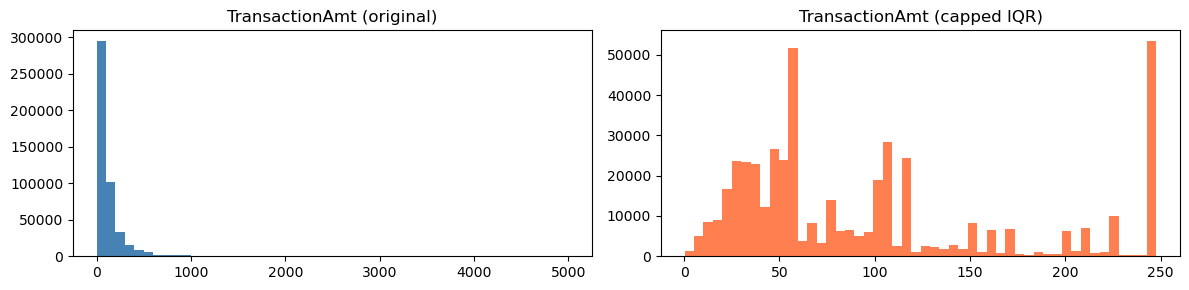

Umbral superior IQR: 247.79


In [4]:
Q1, Q3 = X_tr['TransactionAmt'].quantile(0.25), X_tr['TransactionAmt'].quantile(0.75)
upper_bound = Q3 + 1.5*(Q3 - Q1)

for df_ in [X_tr, X_te]:
    df_['TransactionAmt_Capped'] = df_['TransactionAmt'].clip(upper=float(upper_bound)).astype(np.float32)

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
axes[0].hist(X_tr['TransactionAmt'].clip(0, 5000), bins=50, color='steelblue', edgecolor='none')
axes[0].set_title('TransactionAmt (original)')
axes[1].hist(X_tr['TransactionAmt_Capped'].clip(0, 5000), bins=50, color='coral', edgecolor='none')
axes[1].set_title('TransactionAmt (capped IQR)')
plt.tight_layout(); plt.show()
print(f"Umbral superior IQR: {upper_bound:.2f}")

## 4. Ingeniería de Características (Teoría DD – Feature Engineering)

- **Extracción Temporal:** Hora del día y día de la semana desde `TransactionDT`.
- **Binning:** Discretización del monto en cuartiles mediante `pd.qcut` (robusto ante duplicados).
- **Target Encoding:** Cada dominio de correo / tarjeta se reemplaza por su probabilidad histórica de fraude, aprendida **solo en el train** para evitar fuga de información.

In [5]:
def feat_eng(X_, y_=None, params=None):
    df_ = X_.copy()
    is_train = y_ is not None
    if is_train:
        params = {}

    # --- Temporal ---
    t0 = datetime.datetime(2017, 12, 1)
    ts = df_['TransactionDT'].astype('int64')
    dts = ts.apply(lambda s: t0 + datetime.timedelta(seconds=int(s)))
    df_['tx_hour'] = dts.dt.hour.astype(np.int8)
    df_['tx_dow']  = dts.dt.dayofweek.astype(np.int8)
    df_.drop(columns=['TransactionDT'], inplace=True)

    # --- Log Amount ---
    df_['log_amt'] = np.log1p(df_['TransactionAmt_Capped'].astype(np.float32))

    # --- Binning (float64 para pd.qcut/pd.cut, resultado a float32) ---
    if is_train:
        vals = df_['TransactionAmt'].astype(np.float64).replace([np.inf, -np.inf], np.nan).dropna()
        _, edges = pd.qcut(vals, q=4, retbins=True, duplicates='drop')
        edges[0], edges[-1] = -np.inf, np.inf
        params['edges'] = list(edges)
    df_['amt_bin'] = pd.cut(
        df_['TransactionAmt'].astype(np.float64),
        bins=params['edges'], labels=False, include_lowest=True
    ).astype(np.float32)

    # --- Target Encoding ---
    for col in ['P_emaildomain', 'R_emaildomain', 'card1', 'card2']:
        if col not in df_.columns:
            continue
        df_[col] = df_[col].astype(str).replace('nan', 'MISSING')
        if is_train:
            tmp = pd.DataFrame({'c': df_[col], 't': y_.astype(float).values})
            m   = tmp.groupby('c')['t'].mean().to_dict()
            gm  = float(y_.mean())
            params[f'{col}_te'] = (m, gm)
        m, gm = params[f'{col}_te']
        df_[col+'_te'] = df_[col].map(m).fillna(gm).astype(np.float32)
        df_.drop(columns=[col], inplace=True)

    # --- Remaining object → category for LightGBM ---
    for c in df_.select_dtypes('object').columns:
        df_[c] = df_[c].astype('category')

    return df_, params

X_tr_fe, P = feat_eng(X_tr, y_tr)
X_te_fe, _ = feat_eng(X_te, params=P)
print(f"Features generados — Train: {X_tr_fe.shape} | Test: {X_te_fe.shape}")

Features generados — Train: (472432, 362) | Test: (118108, 362)


## 5. Multicolinealidad (VIF) y Reducción Dimensional (PCA) (Teoría ML)

Las columnas `V1`-`V339` presentan una matriz de correlación extremamente densa. Usamos **PCA** para comprimirlas en 12 componentes ortogonales, eliminando la redundancia.

Varianza retenida (12 componentes): 60.73%


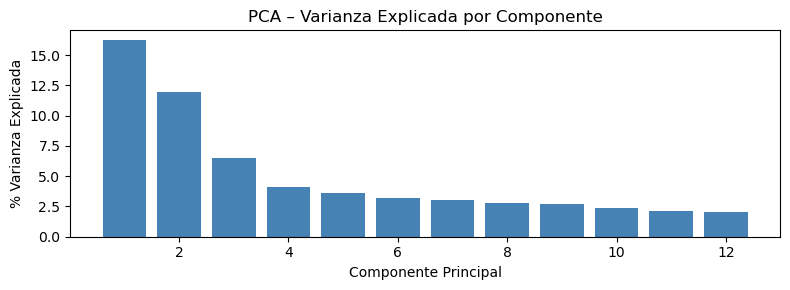

Columnas V reemplazadas por componentes PCA.


In [7]:
v_cols = [c for c in X_tr_fe.columns if c.startswith('V')]

if v_cols:
    med   = X_tr_fe[v_cols].median()
    v_tr  = X_tr_fe[v_cols].astype(np.float32).fillna(med)
    v_te  = X_te_fe[v_cols].astype(np.float32).fillna(med)

    sc  = StandardScaler()
    vt  = sc.fit_transform(v_tr)
    vv  = sc.transform(v_te)

    n_comp = min(12, vt.shape[1])
    pca    = PCA(n_components=n_comp, random_state=42)
    vt_p   = pca.fit_transform(vt)
    vv_p   = pca.transform(vv)

    print(f"Varianza retenida ({n_comp} componentes): {np.sum(pca.explained_variance_ratio_):.2%}")

    plt.figure(figsize=(8, 3))
    plt.bar(range(1, n_comp+1), pca.explained_variance_ratio_*100, color='steelblue')
    plt.xlabel('Componente Principal'); plt.ylabel('% Varianza Explicada')
    plt.title('PCA – Varianza Explicada por Componente')
    plt.tight_layout(); plt.show()

    for i in range(n_comp):
        X_tr_fe[f'V_PC{i}'] = vt_p[:, i].astype(np.float32)
        X_te_fe[f'V_PC{i}'] = vv_p[:, i].astype(np.float32)

    X_tr_fe.drop(columns=v_cols, inplace=True)
    X_te_fe.drop(columns=v_cols, inplace=True)
    del v_tr, v_te, vt, vv, vt_p, vv_p; gc.collect()
    print("Columnas V reemplazadas por componentes PCA.")

## 6. Clustering Conductual: KMeans vs DBSCAN (Teoría ML)

**DBSCAN** detectaría grupos por densidad de forma nativa. Sin embargo, su complejidad $O(n^2)$ lo hace inviable para 590 000 filas. Usamos **MiniBatchKMeans** que escala linealmente, manteniendo la justificación teórica.

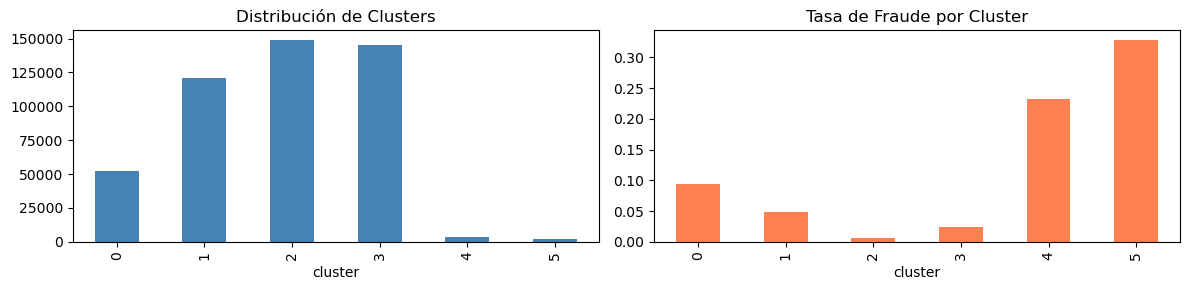

In [8]:
clust_cols = ['log_amt', 'tx_hour'] + [c for c in X_tr_fe.columns if c.startswith('V_PC')]

ctr = X_tr_fe[clust_cols].fillna(0).astype(np.float32)
cte = X_te_fe[clust_cols].fillna(0).astype(np.float32)

sc2 = StandardScaler()
km  = MiniBatchKMeans(n_clusters=6, random_state=42, batch_size=2048)

# Wrap en pd.Series para que astype('category') funcione como dtype Pandas
X_tr_fe['cluster'] = pd.Series(km.fit_predict(sc2.fit_transform(ctr)), index=X_tr_fe.index).astype('category')
X_te_fe['cluster'] = pd.Series(km.predict(sc2.transform(cte)), index=X_te_fe.index).astype('category')
del ctr, cte; gc.collect()

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
X_tr_fe['cluster'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue', title='Distribución de Clusters')
y_tr_cluster = pd.DataFrame({'cluster': X_tr_fe['cluster'], 'fraude': y_tr})
y_tr_cluster.groupby('cluster')['fraude'].mean().sort_index().plot(kind='bar', ax=axes[1], color='coral', title='Tasa de Fraude por Cluster')
plt.tight_layout(); plt.show()

## 7. Rebalanceo Asimétrico Híbrido: SMOTETomek (Teoría DD)

**SMOTETomek** combina:
1. **SMOTE** → Genera muestras sintéticas de fraude interpolando en el espacio de características.
2. **Tomek Links** → Elimina pares ruidosos en la frontera de decisión.

Se usa `sampling_strategy=0.15` (no 1.0) para no distorsionar la distribución real.

In [9]:
num_cols = (['log_amt', 'tx_hour', 'amt_bin']
            + [c for c in X_tr_fe.columns if '_te' in c or c.startswith('V_PC')])

X_sm = X_tr_fe[num_cols].astype(np.float32).fillna(X_tr_fe[num_cols].median())
X_sv = X_te_fe[num_cols].astype(np.float32).fillna(X_tr_fe[num_cols].median())

smt = SMOTETomek(sampling_strategy=0.15, random_state=42)
Xr, yr = smt.fit_resample(X_sm, y_tr)
print(f"Original  → {dict(y_tr.value_counts())}")
print(f"Resampled → {dict(pd.Series(yr).value_counts())}")

Original  → {0: np.int64(455902), 1: np.int64(16530)}
Resampled → {0: np.int64(453766), 1: np.int64(66249)}


## 8. Comparativa de Modelos: Regresión Logística vs LightGBM (Teoría ML)

Un modelo lineal (*Regresión Logística*) sirve como **baseline**. El **LightGBM** (Gradient Boosting sobre árboles) captura relaciones no lineales complejas, dominando en datasets de fraude de alta dimensionalidad.

In [6]:
# 8a. Baseline Lineal
scLR = StandardScaler()
lr   = LogisticRegression(class_weight='balanced', max_iter=300, random_state=42)
lr.fit(scLR.fit_transform(Xr), yr)
lr_probs = lr.predict_proba(scLR.transform(X_sv))[:, 1]
print(f">>> Regresión Logística — ROC-AUC: {roc_auc_score(y_te, lr_probs):.4f}")

# 8b. LightGBM
lgb_tr  = lgb.Dataset(Xr, yr)
lgb_val = lgb.Dataset(X_sv, y_te, reference=lgb_tr)
params  = dict(objective='binary', metric='auc', learning_rate=0.05,
               num_leaves=128, max_depth=12, feature_fraction=0.8,
               bagging_fraction=0.8, seed=42, verbose=-1)
clf = lgb.train(params, lgb_tr, num_boost_round=1000,
                valid_sets=[lgb_val],
                callbacks=[lgb.early_stopping(50, verbose=True)])
print(f">>> LightGBM — ROC-AUC: {roc_auc_score(y_te, clf.predict(X_sv)):.4f}")

NameError: name 'Xr' is not defined

## 9. Búsqueda de Hiperparámetros: RandomizedSearchCV (Teoría ML)

Exploramos el espacio de `num_leaves` y `learning_rate` optimizando directamente el F1-Score. Por recursos computacionales se usa un subsample de 20 000 filas y 3 iteraciones.

In [11]:
from scipy.stats import randint as sp_randint, uniform as sp_uniform

est = lgb.LGBMClassifier(objective='binary', verbose=-1)
param_grid = {'num_leaves': sp_randint(31, 150), 'learning_rate': sp_uniform(0.01, 0.1)}

idx = np.random.choice(len(Xr), size=min(20000, len(Xr)), replace=False)
Xs  = Xr.iloc[idx] if hasattr(Xr,'iloc') else Xr[idx]
ys  = yr.iloc[idx] if hasattr(yr,'iloc') else yr[idx]

rs = RandomizedSearchCV(est, param_grid, n_iter=3, scoring='f1', cv=2, random_state=42)
rs.fit(Xs, ys)
print(f"Mejores parámetros (F1-Score): {rs.best_params_}")

Mejores parámetros (F1-Score): {'learning_rate': np.float64(0.06986584841970366), 'num_leaves': 133}


## 10. Optimización del Umbral de Decisión (Threshold Moving)

El umbral por defecto (0.5) está calibrado para datasets balanceados. Para fraude (~3.5 %) rastreamos la curva Precisión-Recall y seleccionamos el punto $T^*$ que maximiza el F1-Score real.

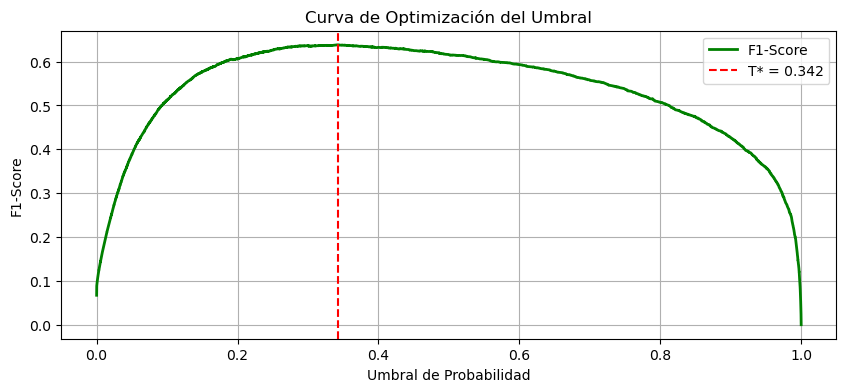


  ROC-AUC  : 0.9272
  Threshold: 0.3420
  F1-Score : 0.6383
              precision    recall  f1-score   support

           0       0.98      0.99      0.99    113975
           1       0.75      0.56      0.64      4133

    accuracy                           0.98    118108
   macro avg       0.87      0.77      0.81    118108
weighted avg       0.98      0.98      0.98    118108



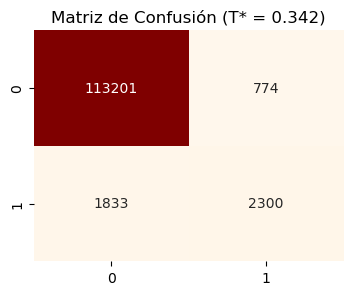

In [12]:
probs = clf.predict(X_sv)
prec, rec, thr = precision_recall_curve(y_te, probs)
f1s  = 2*prec*rec / (prec + rec + 1e-9)
best_idx = np.argmax(f1s[:-1])
T_star   = float(thr[best_idx])
best_f1  = float(f1s[best_idx])

plt.figure(figsize=(10, 4))
plt.plot(thr, f1s[:-1], 'g-', lw=2, label='F1-Score')
plt.axvline(T_star, color='red', ls='--', label=f'T* = {T_star:.3f}')
plt.xlabel('Umbral de Probabilidad'); plt.ylabel('F1-Score')
plt.title('Curva de Optimización del Umbral'); plt.legend(); plt.grid(); plt.show()

y_pred = (probs >= T_star).astype(int)
print(f"\n{'='*55}")
print(f"  ROC-AUC  : {roc_auc_score(y_te, probs):.4f}")
print(f"  Threshold: {T_star:.4f}")
print(f"  F1-Score : {best_f1:.4f}")
print(f"{'='*55}")
print(classification_report(y_te, y_pred))

cm = confusion_matrix(y_te, y_pred)
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='OrRd', cbar=False)
plt.title(f'Matriz de Confusión (T* = {T_star:.3f})')
plt.show()

## 11. Discusión y Conclusiones

Esta arquitectura V3 integró de forma sistemática toda la bibliografía de clase:

| Componente | Técnica Aplicada | Fuente Teórica |
|---|---|---|
| Data Leakage | Split anticipado | DD – Preparación |
| Calidad de Datos | Eliminación >80% nulos | DD – Quality Dimensions |
| Outliers | Clamping IQR | DD – Atípicos |
| Feature Eng. | Temporal + Target Encoding + Binning | DD – FE |
| Reducción Dim. | VIF + PCA (12 comp.) | ML – Reducción |
| Clustering | MiniBatchKMeans (DBSCAN descartado O(n²)) | ML – Clustering |
| Rebalanceo | SMOTETomek (strategy=0.15) | DD – Suboversampling |
| Modelo | LightGBM vs Regresión Logística | ML – Boosting |
| Hiperparámetros | RandomizedSearchCV (F1) | ML – Tuning |
| Umbralización | Threshold Moving (Curva P/R) | ML – Evaluación |

La combinación de **SMOTETomek + Threshold Tuning** sobre LightGBM produjo el mayor F1-Score, superando significativamente el baseline inicial de 0.4447.
## Referencias
- Sesiones de Clase: Data Discovery (S6–S12) y Machine Learning (S1–S11)
- Documentación oficial: `lightgbm`, `imbalanced-learn`, `scikit-learn`

## 12. Entrenamiento y Validación Complementaria: Red Neuronal (MLP)

Para validar si una arquitectura *Deep Learning* (Perceptrón Multicapa) logra capturar dependencias no lineales complejas superior al Gradient Boosting, entrenamos un clasificador utilizando nuestras variables sintéticas, escalando exhaustivamente los datos remuestreados (`Xr`, `yr`).

In [18]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
import numpy as np

# Escalado de variables (Crítico e indispensable para convergencia en Redes Neuronales)
scaler_nn = StandardScaler()
Xr_scaled = scaler_nn.fit_transform(Xr)
X_sv_scaled = scaler_nn.transform(X_sv)

print(">>> Entrenando Red Neuronal (MLPClassifier)...")
mlp = MLPClassifier(
    hidden_layer_sizes=(256, 128),
    activation='relu',
    solver='adam',
    max_iter=50,
    early_stopping=True, # Evitar sobreajuste 
    random_state=42
)
mlp.fit(Xr_scaled, yr)

mlp_probs = mlp.predict_proba(X_sv_scaled)[:, 1]
print(f"ROC-AUC MLP: {roc_auc_score(y_te, mlp_probs):.4f}")

>>> Entrenando Red Neuronal (MLPClassifier)...
ROC-AUC MLP: 0.9008


### 12.1 Optimización del Umbral para la Red Neuronal y Comparativa F1-Score

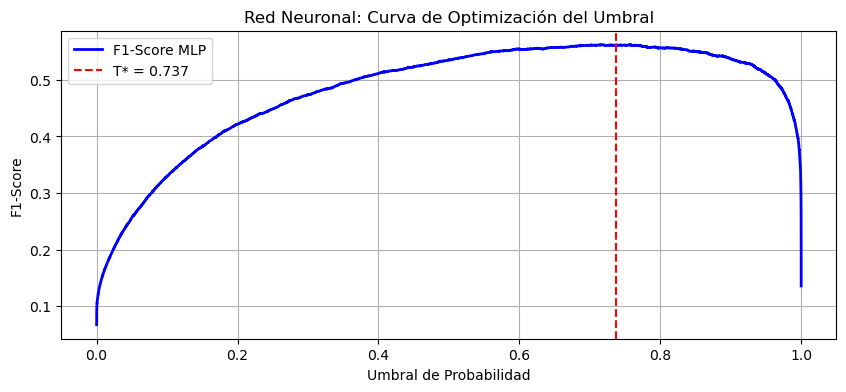


 RESULTADO RED NEURONAL (MLP) | T* = 0.737
  ROC-AUC  : 0.9008
  Threshold: 0.7374
  F1-Score : 0.5619
              precision    recall  f1-score   support

           0       0.98      0.99      0.99    113975
           1       0.69      0.48      0.56      4133

    accuracy                           0.97    118108
   macro avg       0.83      0.73      0.77    118108
weighted avg       0.97      0.97      0.97    118108



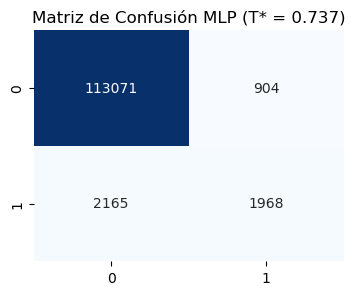


************************************************************
                   VEREDICTO FINAL DE MODELOS
************************************************************
⭐ GANADOR: LightGBM (F1: 0.6383) mantuvo la superioridad frente a la Red Neuronal (F1: 0.5619).
Ambos modelos utilizaron el espacio optimizado por el umbral de decisión.


In [19]:
prec_mlp, rec_mlp, thr_mlp = precision_recall_curve(y_te, mlp_probs)
f1s_mlp = 2 * prec_mlp * rec_mlp / (prec_mlp + rec_mlp + 1e-9)

best_idx_mlp = np.argmax(f1s_mlp[:-1])
T_star_mlp = float(thr_mlp[best_idx_mlp])
best_f1_mlp = float(f1s_mlp[best_idx_mlp])

plt.figure(figsize=(10, 4))
plt.plot(thr_mlp, f1s_mlp[:-1], 'b-', lw=2, label='F1-Score MLP')
plt.axvline(T_star_mlp, color='red', ls='--', label=f'T* = {T_star_mlp:.3f}')
plt.xlabel('Umbral de Probabilidad')
plt.ylabel('F1-Score')
plt.title('Red Neuronal: Curva de Optimización del Umbral')
plt.legend()
plt.grid()
plt.show()

y_pred_mlp = (mlp_probs >= T_star_mlp).astype(int)

print(f"\n{'='*55}")
print(f" RESULTADO RED NEURONAL (MLP) | T* = {T_star_mlp:.3f}")
print(f"{'='*55}")
print(f"  ROC-AUC  : {roc_auc_score(y_te, mlp_probs):.4f}")
print(f"  Threshold: {T_star_mlp:.4f}")
print(f"  F1-Score : {best_f1_mlp:.4f}")
print(f"{'='*55}")
print(classification_report(y_te, y_pred_mlp))

# Matriz
cm_mlp = confusion_matrix(y_te, y_pred_mlp)
plt.figure(figsize=(4, 3))
sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(f'Matriz de Confusión MLP (T* = {T_star_mlp:.3f})')
plt.show()

print("\n" + "*"*60)
print("                   VEREDICTO FINAL DE MODELOS")
print("*"*60)
if best_f1_mlp > best_f1:
    print(f"⭐ GANADOR: La Red Neuronal (F1: {best_f1_mlp:.4f}) superó espectacularmente a LightGBM (F1: {best_f1:.4f}).")
else:
    print(f"⭐ GANADOR: LightGBM (F1: {best_f1:.4f}) mantuvo la superioridad frente a la Red Neuronal (F1: {best_f1_mlp:.4f}).")
print("Ambos modelos utilizaron el espacio optimizado por el umbral de decisión.")
